# Imports

### Visualization

In [36]:
import matplotlib.pyplot as plt
import nd2
import numpy as np
from pathlib import Path
import re
import math

def find_nd2_file_for_tile(well: str, tile: int, files: list[Path], pattern: re.Pattern) -> Path | None:
    point_str = f"{tile:03d}"
    for file in files:
        match = pattern.match(file.name)
        if match and match.group("well") == well and match.group("point") == point_str:
            return file
    return None

def load_dapi_image_from_nd2(file: Path, preferred_channel: str = "DAPI") -> np.ndarray | None:
    try:
        # Open the file with the recommended approach for nd2 library
        with nd2.ND2File(str(file)) as nd2_file:
            # Try different approaches to get channel names based on nd2 library version
            channels = []
            
            # Try to access channel names directly from the file
            if hasattr(nd2_file, 'channel_names'):
                channels = nd2_file.channel_names
            elif hasattr(nd2_file, 'metadata') and hasattr(nd2_file.metadata, 'channels'):
                # Attempt to extract channel metadata
                try:
                    channels = [str(ch) for ch in nd2_file.metadata.channels]
                except Exception:
                    # If that fails, try a different approach based on available metadata
                    if hasattr(nd2_file, 'experiment') and hasattr(nd2_file.experiment, 'channels'):
                        channels = [str(ch) for ch in nd2_file.experiment.channels]
            
            # If we still don't have channels, create generic ones
            if not channels and hasattr(nd2_file, 'shape'):
                channel_count = nd2_file.shape[0] if len(nd2_file.shape) > 2 else 1
                channels = [f"Channel_{i}" for i in range(channel_count)]
            
            # Print channel info for debugging
            print(f"Available channels in {file.name}: {channels}")
            
            # Find DAPI channel index
            dapi_index = None
            for i, ch_name in enumerate(channels):
                if preferred_channel.upper() in ch_name.upper():
                    dapi_index = i
                    break
            
            if dapi_index is not None:
                print(f"Using channel index {dapi_index} for {preferred_channel}")
                
                # Load the image data
                try:
                    # First approach: Try using get_frame method
                    if hasattr(nd2_file, 'get_frame'):
                        try:
                            # For multi-channel files, specify the channel
                            if len(channels) > 1:
                                return np.array(nd2_file.get_frame(c=dapi_index))
                            else:
                                return np.array(nd2_file.get_frame())
                        except Exception as e:
                            print(f"get_frame failed: {e}")
                    
                    # Second approach: For older versions or different API patterns
                    if hasattr(nd2_file, 'asarray'):
                        data = nd2_file.asarray()
                        print(f"Data shape: {data.shape}")
                        
                        # Handle the case where first dimension is channels
                        if len(data.shape) >= 3:
                            if data.shape[0] <= 5:  # Likely channels first
                                return np.array(data[dapi_index])
                            else:  # Channels might be in a different dimension
                                for dim in range(len(data.shape)):
                                    if data.shape[dim] <= 5:  # This dimension might be channels
                                        # Extract the DAPI channel along this dimension
                                        slices = [slice(None)] * len(data.shape)
                                        slices[dim] = dapi_index
                                        return np.array(data[tuple(slices)])
                                        
                        # Fallback if we couldn't find a suitable dimension
                        return np.array(data)
                        
                    # Last resort: direct array conversion
                    else:
                        data = np.array(nd2_file)
                        print(f"Direct conversion data shape: {data.shape}")
                        
                        # If data is 3D and first dimension is small, assume it's channels
                        if len(data.shape) == 3 and data.shape[0] <= 5:
                            return data[dapi_index]
                        else:
                            return data
                        
                except Exception as inner_e:
                    print(f"Error extracting frame from {file.name}: {inner_e}")
                    import traceback
                    traceback.print_exc()
            else:
                print(f"{file.name}: Channel '{preferred_channel}' not found in {channels}")
                
    except Exception as e:
        print(f"Error reading {file.name}: {e}")
        import traceback
        traceback.print_exc()
        
    return None

def display_tile_site_pair(well: str,
                          tile: int,
                          site: int,
                          tile_nd2_dir: Path,
                          site_nd2_dir: Path,
                          tile_pattern: re.Pattern,
                          site_pattern: re.Pattern):
    print(f"Displaying Tile {tile} and Site {site} from Well {well}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

    tile_file = find_nd2_file_for_tile(well, tile, list(tile_nd2_dir.glob("*.nd2")), tile_pattern)
    tile_img = load_dapi_image_from_nd2(tile_file) if tile_file else None

    site_file = find_nd2_file_for_tile(well, site, list(site_nd2_dir.glob("*.nd2")), site_pattern)
    site_img = load_dapi_image_from_nd2(site_file) if site_file else None

    ax_tile = axes[0]
    if tile_img is not None:
        if len(tile_img.shape) == 3 and tile_img.shape[0] <= 5:
            ax_tile.imshow(tile_img[0], cmap='gray')
        else:
            ax_tile.imshow(tile_img, cmap='gray')
        ax_tile.set_title(f"Tile {tile}", fontsize=10)
    else:
        ax_tile.set_title(f"No tile image for {tile}", fontsize=10)
    ax_tile.axis('off')

    ax_site = axes[1]
    if site_img is not None:
        if len(site_img.shape) == 3 and site_img.shape[0] <= 5:
            ax_site.imshow(site_img[0], cmap='gray')
        else:
            ax_site.imshow(site_img, cmap='gray')
        ax_site.set_title(f"Site {site}", fontsize=10)
    else:
        ax_site.set_title(f"No site image for {site}", fontsize=10)
    ax_site.axis('off')

    plt.tight_layout()
    plt.show()


### file_utils

In [27]:
"""Utility functions for handling and filtering sample file paths in the BrieFlow pipeline."""

from pathlib import Path

from pyarrow.parquet import ParquetFile
import pyarrow as pa
import pandas as pd
import numpy as np

# Mapping of metadata keys to filename prefixes and data types
FILENAME_METADATA_MAPPING = {
    "plate": ["P-", str],
    "well": ["W-", str],
    "tile": ["T-", int],
    "cycle": ["C-", int],
    "cell_class": ["CeCl-", str],
    "channel_combo": ["ChCo-", str],
    "gene": ["G-", str],
    "sgrna": ["SG-", str],
    "channel": ["CH-", str],
    "leiden_resolution": ["LR-", float],
    "cluster_benchmark": ["CB-", str],
}


def get_filename(data_location: dict, info_type: str, file_type: str) -> str:
    """Generate a structured filename based on data location, information type, and file type.

    Args:
        data_location (dict): Dictionary containing location info like well, tile, and cycle.
        info_type (str): Type of information (e.g., 'cell_features', 'sbs_reads').
        file_type (str): File extension/type (e.g., 'tsv', 'parquet', 'tiff').

    Returns:
        str: Structured filename.
    """
    parts = []

    for metadata_key, metadata_value in data_location.items():
        if metadata_key in FILENAME_METADATA_MAPPING:
            prefix, _ = FILENAME_METADATA_MAPPING[metadata_key]
            parts.append(f"{prefix}{metadata_value}")
        else:
            print(f"Unknown metadata key: {metadata_key}")

    prefix = "_".join(parts)
    filename = (
        f"{prefix}__{info_type}.{file_type}" if prefix else f"{info_type}.{file_type}"
    )

    return filename


def parse_filename(file_path: str) -> tuple:
    """Parse a structured filename from a file path to extract data location, information type, and file type.

    Args:
        file_path (str): Full file path or filename, e.g., '/path/to/W_A1_T02_C03__cell_features.tsv'.

    Returns:
        tuple: A tuple containing:
            - metadata (dict): Dictionary with keys like 'well', 'tile', 'cycle' as applicable.
            - info_type (str): The type of information (e.g., 'cell_features').
            - file_type (str): The file extension/type (e.g., 'tsv').
    """
    # Convert the input to a Path object
    path = Path(file_path)

    # Extract the filename and file extension
    filename = path.stem
    file_type = path.suffix.lstrip(".")

    # Split the filename into main parts
    parts = filename.split("__")

    # Initialize metadata dictionary and info_type variable
    metadata = {}
    info_type = None

    # Parse data location part
    if len(parts) == 2:
        location_part, info_type = parts
        elements = location_part.split("_")

        for element in elements:
            for key, (prefix, data_type) in FILENAME_METADATA_MAPPING.items():
                if element.startswith(prefix):
                    # Extract and convert the value based on the data type
                    value = element[len(prefix) :]
                    metadata[key] = data_type(value)
                    break  # Stop checking other prefixes for this element
    else:
        # If no location part, the first part is the info_type
        info_type = parts[0]

    return metadata, info_type, file_type


def load_parquet_subset(full_df_fp, n_rows=50000):
    """Load a fixed number of rows from an parquet file without loading entire file into memory.

    Args:
        full_df_fp (str): Path to parquet file.
        n_rows (int): Number of rows to get.

    Returns:
        pd.DataFrame: Subset of the data with combined blocks.
    """
    print(f"Reading first {n_rows:,} rows from {full_df_fp}")

    # read the first n_rows of the file path
    df = ParquetFile(full_df_fp)
    row_subset = next(df.iter_batches(batch_size=n_rows))
    df = pa.Table.from_batches([row_subset]).to_pandas()

    return df


def validate_dtypes(df):
    """Convert DataFrame columns to the most specific data type possible with the following rules.

    - Convert object to bool or string if possible
    - Convert strings to int float if possible
    - Convert floats to int if possible

    Args:
        df : pandas.DataFrame
            The DataFrame to optimize

    Returns:
        pandas.DataFrame
            A new DataFrame with optimized dtypes
    """
    for col in df.columns:
        # Skip columns that are already int
        if pd.api.types.is_integer_dtype(df[col]):
            continue

        # Convert object to bool if possible, else to string
        if pd.api.types.is_object_dtype(df[col]):
            lowered = df[col].dropna().astype(str).str.lower()
            if lowered.isin(["true", "false"]).all():
                df[col] = (
                    df[col].astype(str).str.lower().map({"true": True, "false": False})
                )
            else:
                try:
                    df[col] = df[col].astype("string")
                except ValueError:
                    pass

        # Convert string to float if possible
        if pd.api.types.is_string_dtype(df[col]):
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                pass

        # Convert float to int if possible
        if pd.api.types.is_float_dtype(df[col]):
            col_nonan = df[col].dropna()
            if len(col_nonan) == 0 or np.allclose(
                col_nonan, col_nonan.round(), rtol=1e-10, atol=1e-10
            ):
                try:
                    df[col] = df[col].astype("Int64")
                except TypeError:
                    pass

    return df


### hash

In [28]:
"""Utility functions for hashing cells in merge module.

These include:
- Preprocessing cell location dataframes for hashing.
- Generating hashed Delaunay triangulation for cells.
- Performing initial and multistep alignment.
- Extraction rotations from a 2D array.
"""

import warnings
import multiprocessing
from collections.abc import Iterable

import pandas as pd
import numpy as np
from scipy.spatial import Delaunay
from scipy.spatial.distance import cdist
from sklearn.linear_model import RANSACRegressor
from joblib import Parallel, delayed


def hash_cell_locations(cell_locations_df):
    """Generate hashed Delaunay triangulation for process info at screen level.

    1) Preprocess table of `i, j` coordinates (typically nuclear centroids) to ensure at least 4 valid cells per tile.
    2) Computes a Delaunay triangulation of the input points.

    Args:
        cell_locations_df (pandas.DataFrame): Table of points with columns `i`, `j`, and tile of cell.

    Returns:
        pandas.DataFrame: Table containing a hashed Delaunay triangulation, with one row per simplex (triangle).
    """
    # Ensure that i and j are not null, at least 4 cells per tile
    cell_locations_df = cell_locations_df[
        cell_locations_df["i"].notnull() & cell_locations_df["j"].notnull()
    ]
    cell_locations_df = cell_locations_df.groupby(["well", "tile"]).filter(
        lambda x: len(x) > 3
    )

    # Find triangles across well with parallel processing
    cell_locations_hash = cell_locations_df.pipe(
        gb_apply_parallel, ["tile"], find_triangles
    )

    return cell_locations_hash


def find_triangles(cell_locations_df):
    """Generates a hashed Delaunay triangulation for input points.

    Processes a table of `i, j` coordinates (typically nuclear centroids) and computes a Delaunay triangulation of the input points. Each tile/site is processed independently. The triangulations for all tiles/sites within a single well are concatenated and used as input to `multistep_alignment`.

    Args:
        cell_locations_df (pandas.DataFrame): Table of points with columns `i` and `j`.

    Returns:
        pandas.DataFrame: Table containing a hashed Delaunay triangulation, with one row per simplex (triangle).
    """
    # Extract the coordinates from the dataframe and compute the Delaunay triangulation
    v, c = get_vectors(cell_locations_df[["i", "j"]].values)

    # Create a dataframe from the vectors and rename the columns with a prefix 'V_'
    df_vectors = pd.DataFrame(v).rename(columns="V_{0}".format)

    # Create a dataframe from the coordinates and rename the columns with a prefix 'c_'
    df_coords = pd.DataFrame(c).rename(columns="c_{0}".format)

    # Concatenate the two dataframes along the columns
    df_combined = pd.concat([df_vectors, df_coords], axis=1)

    # Assign a new column 'magnitude' which is the Euclidean distance (magnitude) of each vector
    df_result = df_combined.assign(magnitude=lambda x: x.eval("(V_0**2 + V_1**2)**0.5"))

    return df_result


def get_vectors(X):
    """Calculates edge vectors and centers for all faces in the Delaunay triangulation.

    Computes the nine edge vectors and centers for each face in the Delaunay triangulation of the given point array `X`.

    Args:
        X (numpy.ndarray): Array of points to be triangulated.

    Returns:
        tuple:
            - numpy.ndarray: Array of shape (n_faces, 18) containing the vector displacements for the nine edges of each triangle.
            - numpy.ndarray: Array of shape (n_faces, 2) containing the center points of each triangle.
    """
    dt = Delaunay(X)  # Create Delaunay triangulation of the points
    vectors, centers = [], []  # Initialize lists to store vectors and centers

    for i in range(dt.simplices.shape[0]):
        # Skip triangles with an edge on the outer boundary
        if (dt.neighbors[i] == -1).any():
            continue

        result = nine_edge_hash(
            dt, i
        )  # Get the nine edge vectors for the current triangle
        # Some rare event where hashing fails
        if result is None:
            continue

        _, v = result  # Unpack the result to get the vectors
        c = X[dt.simplices[i], :].mean(axis=0)  # Calculate the center of the triangle
        vectors.append(v)  # Append the vectors to the list
        centers.append(c)  # Append the center to the list

    # Convert lists to numpy arrays and reshape vectors to (n_faces, 18)
    return np.array(vectors).reshape(-1, 18), np.array(centers)


def nine_edge_hash(dt, i):
    """Extracts vector displacements for edges connected to a specified triangle in a Delaunay triangulation.

    For triangle `i` in the Delaunay triangulation `dt`, computes the vector displacements for the 9 edges containing at least one vertex of the triangle. Raises an error if the triangle lies on the outer boundary of the triangulation.

    Example:
        ```python
        dt = Delaunay(X_0)
        i = 0
        segments, vector = nine_edge_hash(dt, i)
        ```

    Args:
        dt (scipy.spatial.Delaunay): Delaunay triangulation object containing points and simplices.
        i (int): Index of the triangle in the Delaunay triangulation.

    Returns:
        tuple:
            - list[tuple]: List of vertex pairs representing the 9 edges.
            - numpy.ndarray: Array containing vector displacements for the 9 edges.
    """
    # Indices of inner three vertices in CCW order
    a, b, c = dt.simplices[i]

    # Reorder vertices so that the edge 'ab' is the longest
    X = dt.points
    start = np.argmax((np.diff(X[[a, b, c, a]], axis=0) ** 2).sum(axis=1) ** 0.5)
    if start == 0:
        order = [0, 1, 2]
    elif start == 1:
        order = [1, 2, 0]
    elif start == 2:
        order = [2, 0, 1]
    a, b, c = np.array([a, b, c])[order]

    # Get indices of outer three vertices connected to the inner vertices
    a_ix, b_ix, c_ix = dt.neighbors[i]
    inner = {a, b, c}
    outer = lambda xs: [x for x in xs if x not in inner][0]

    try:
        bc = outer(dt.simplices[dt.neighbors[i, order[0]]])
        ac = outer(dt.simplices[dt.neighbors[i, order[1]]])
        ab = outer(dt.simplices[dt.neighbors[i, order[2]]])
    except IndexError:
        return None

    if any(x == -1 for x in (bc, ac, ab)):
        error = "triangle on outer boundary, neighbors are: {0} {1} {2}"
        raise ValueError(error.format(bc, ac, ab))

    # Define the 9 edges
    segments = [
        (a, b),
        (b, c),
        (c, a),
        (a, ab),
        (b, ab),
        (b, bc),
        (c, bc),
        (c, ac),
        (a, ac),
    ]

    # Extract the vector displacements for the 9 edges
    i_coords = X[segments, 0]
    j_coords = X[segments, 1]
    vector = np.hstack([np.diff(i_coords, axis=1), np.diff(j_coords, axis=1)])

    return segments, vector


def initial_alignment(well_triangles_0, well_triangles_1, initial_sites=8):
    """Identifies matching tiles from two acquisitions with similar Delaunay triangulations within the same well.

    Matches tiles from two datasets based on Delaunay triangulations, assuming minimal cell movement between acquisitions and equivalent segmentations.

    Args:
        well_triangles_0 (pandas.DataFrame): Hashed Delaunay triangulation for all tiles in dataset 0. Produced by concatenating outputs of `find_triangles` for individual tiles of a single well. Must include a `tile` column.
        well_triangles_1 (pandas.DataFrame): Hashed Delaunay triangulation for all sites in dataset 1. Produced by concatenating outputs of `find_triangles` for individual sites of a single well. Must include a `site` column.
        initial_sites (int | list[tuple[int, int]], optional): If an integer, specifies the number of sites sampled from `df_1` for initial brute-force matching of tiles to build the alignment model. If a list of 2-tuples, represents known (tile, site) matches to initialize the alignment model. At least 5 pairs are recommended.

    Returns:
        pandas.DataFrame: Table of possible (tile, site) matches, including rotation and translation transformations. Includes all tested matches, which should be filtered by `score` and `determinant` to retain valid matches.
    """

    # Define a function to work on individual (tile,site) pairs
    def work_on(df_t, df_s):
        rotation, translation, score = evaluate_match(df_t, df_s)
        determinant = None if rotation is None else np.linalg.det(rotation)
        result = pd.Series(
            {
                "rotation": rotation,
                "translation": translation,
                "score": score,
                "determinant": determinant,
            }
        )
        return result

    arr = []
    for tile, site in initial_sites:
        result = work_on(
            well_triangles_0.query("tile==@tile"), well_triangles_1.query("site==@site")
        )
        result.at["site"] = site
        result.at["tile"] = tile
        arr.append(result)
    df_initial = pd.DataFrame(arr)

    return df_initial


def evaluate_match(
    vec_centers_0, vec_centers_1, threshold_triangle=0.3, threshold_point=2
):
    """Evaluates the match between two sets of vectors and centers.

    Computes the transformation parameters (rotation and translation) and evaluates the quality of the match between two datasets based on their vectors and centers.

    Args:
        vec_centers_0 (pandas.DataFrame): DataFrame containing the first set of vectors and centers.
        vec_centers_1 (pandas.DataFrame): DataFrame containing the second set of vectors and centers.
        threshold_triangle (float, optional): Threshold for matching triangles. Defaults to 0.3.
        threshold_point (float, optional): Threshold for matching points. Defaults to 2.

    Returns:
        tuple:
            - numpy.ndarray: Rotation matrix of the transformation.
            - numpy.ndarray: Translation vector of the transformation.
            - float: Score of the transformation based on the matching points.
    """
    V_0, c_0 = get_vc(
        vec_centers_0
    )  # Extract vectors and centers from the first DataFrame
    V_1, c_1 = get_vc(
        vec_centers_1
    )  # Extract vectors and centers from the second DataFrame

    i0, i1, distances = nearest_neighbors(
        V_0, V_1
    )  # Find nearest neighbors between the vectors

    # Filter triangles based on distance threshold
    filt = distances < threshold_triangle
    X, Y = c_0[i0[filt]], c_1[i1[filt]]  # Get the matching centers

    # Minimum number of matching triangles required to proceed
    if sum(filt) < 5:
        return None, None, -1

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        # Use matching triangles to define transformation
        model = RANSACRegressor()
        model.fit(X, Y)  # Fit the RANSAC model to the matching centers

    rotation = model.estimator_.coef_  # Extract rotation matrix
    translation = model.estimator_.intercept_  # Extract translation vector

    # Score transformation based on the triangle centers
    distances = cdist(model.predict(c_0), c_1, metric="sqeuclidean")
    threshold_region = 50  # Threshold for the region to consider
    filt = np.sqrt(distances.min(axis=0)) < threshold_region
    score = (
        np.sqrt(distances.min(axis=0))[filt] < threshold_point
    ).mean()  # Calculate score

    return rotation, translation, score  # Return rotation, translation, and score


def get_vc(vec_centers, normalize=True):
    """Extracts vectors and centers from the DataFrame, with optional normalization of vectors.

    Args:
        vec_centers (pandas.DataFrame): DataFrame containing vectors and centers.
        normalize (bool, optional): Whether to normalize the vectors. Defaults to True.

    Returns:
        tuple:
            - numpy.ndarray: Array of vectors.
            - numpy.ndarray: Array of centers.
    """
    V, c = (
        vec_centers.filter(like="V").values,
        vec_centers.filter(like="c").values,
    )  # Extract vectors and centers
    if normalize:
        V = (
            V / vec_centers["magnitude"].values[:, None]
        )  # Normalize the vectors by their magnitudes
    return V, c  # Return vectors and centers


def nearest_neighbors(V_0, V_1):
    """Computes the nearest neighbors between two sets of vectors.

    Args:
        V_0 (numpy.ndarray): First set of vectors.
        V_1 (numpy.ndarray): Second set of vectors.

    Returns:
        tuple:
            - numpy.ndarray: Indices of the nearest neighbors in `V_0`.
            - numpy.ndarray: Indices of the nearest neighbors in `V_1`.
            - numpy.ndarray: Distances between the nearest neighbors.
    """
    Y = cdist(V_0, V_1, metric="sqeuclidean")  # Compute squared Euclidean distances
    distances = np.sqrt(
        Y.min(axis=1)
    )  # Compute the smallest distances and take the square root
    ix_0 = np.arange(V_0.shape[0])  # Indices of V_0
    ix_1 = Y.argmin(axis=1)  # Indices of nearest neighbors in V_1
    return ix_0, ix_1, distances  # Return indices and distances


def multistep_alignment(
    well_triangles_0,
    well_triangles_1,
    well_locations_0,
    well_locations_1,
    det_range=(1.125, 1.186),
    score=0.1,
    initial_sites=8,
    batch_size=180,
    n_jobs=None,
):
    """Find tiles of two different acquisitions with matching Delaunay triangulations within the same well.

    Cells must not have moved significantly between acquisitions, and segmentations should be approximately equivalent.

    Args:
        well_triangles_0 (pandas.DataFrame): Hashed Delaunay triangulation for all tiles of dataset 0. Produced by
            concatenating outputs of `find_triangles` from individual tiles of a single well. Expects a `tile` column.
        well_triangles_1 (pandas.DataFrame): Hashed Delaunay triangulation for all sites of dataset 1. Produced by
            concatenating outputs of `find_triangles` from individual sites of a single well. Expects a `site` column.
        well_locations_0 (pandas.DataFrame): Table of global coordinates for each tile acquisition to match tiles
            of `well_triangles_0`. Expects `tile` as index and two columns of coordinates.
        well_locations_1 (pandas.DataFrame): Table of global coordinates for each site acquisition to match sites
            of `well_triangles_1`. Expects `site` as index and two columns of coordinates.
        det_range (tuple, optional): Range of acceptable values for the determinant of the rotation matrix
            when evaluating an alignment of a tile-site pair. The determinant measures scaling consistency
            within microscope acquisition settings. Defaults to (1.125, 1.186).
        score (float, optional): Threshold score value for filtering valid matches from spurious ones.
            Used for initial alignment. Defaults to 0.1.
        initial_sites (int | list[tuple], optional): If int, the number of sites to sample from `well_triangles_1` for initial
            brute force matching to build a global alignment model. If a list of 2-tuples, represents known
            (tile, site) matches to start building the model. Defaults to 8.
        batch_size (int, optional): Number of (tile, site) matches to evaluate per batch during global
            alignment model updates. Defaults to 180.
        n_jobs (int, optional): Number of parallel jobs to deploy using joblib. Defaults to None.

    Returns:
        pandas.DataFrame: Table of possible (tile, site) matches with corresponding rotation and translation
        transformations. All tested matches are included; query based on `score` and `determinant` to filter valid matches.
    """
    # If n_jobs is not provided, set it to one less than the number of CPU cores
    if n_jobs is None:
        n_jobs = multiprocessing.cpu_count() - 1

    # Define a function to work on individual (tile,site) pairs
    def work_on(tiles_df, sites_df):
        rotation, translation, score = evaluate_match(tiles_df, sites_df)
        determinant = None if rotation is None else np.linalg.det(rotation)
        result = pd.Series(
            {
                "rotation": rotation,
                "translation": translation,
                "score": score,
                "determinant": determinant,
            }
        )
        return result

    # use initial_sites directly to determine initial matches
    arr = []
    for tile, site in initial_sites:
        result = work_on(
            well_triangles_0.query("tile==@tile"),
            well_triangles_1.query("site==@site"),
        )
        result.at["site"] = site
        result.at["tile"] = tile
        arr.append(result)
    df_initial = pd.DataFrame(arr)

    # Unpack det_range tuple into d0 and d1
    d0, d1 = det_range

    # Define the gate condition for filtering matches based on determinant and score
    gate = "@d0 <= determinant <= @d1 & score > @score"

    # Initialize alignments list with the initial matches
    alignments = [df_initial.query(gate)]

    # Main loop for iterating until convergence
    while True:
        # Concatenate alignments and remove duplicates
        df_align = pd.concat(alignments, sort=True).drop_duplicates(["tile", "site"])

        # Extract tested and matched pairs
        tested = df_align.reset_index()[["tile", "site"]].values
        matches = df_align.query(gate).reset_index()[["tile", "site"]].values

        # Prioritize candidate pairs based on certain criteria
        candidates = prioritize(well_locations_0, well_locations_1, matches)
        candidates = remove_overlap(candidates, tested)

        print("matches so far: {0} / {1}".format(len(matches), df_align.shape[0]))

        # Prepare data for parallel processing
        work = []
        d_0 = dict(list(well_triangles_0.groupby("tile")))
        d_1 = dict(list(well_triangles_1.groupby("site")))
        for ix_0, ix_1 in candidates[:batch_size]:
            if ix_0 in d_0 and ix_1 in d_1:  # Only process if both keys exist
                work.append([d_0[ix_0], d_1[ix_1]])
            else:
                print(f"Skipping tile {ix_0}, site {ix_1} - not found in data")

        if not work:  # If no valid pairs found, end alignment
            print("No valid pairs to process")
            break

        # Perform parallel processing of work
        df_align_new = pd.concat(
            Parallel(n_jobs=n_jobs)(delayed(work_on)(*w) for w in work), axis=1
        ).T.assign(
            tile=[t for t, _ in candidates[: len(work)]],
            site=[s for _, s in candidates[: len(work)]],
        )

        # Append new alignments to the list
        alignments += [df_align_new]

        if len(df_align_new.query(gate)) == 0:
            break

    return df_align


def gb_apply_parallel(df, cols, func, n_jobs=None, backend="loky"):
    """Apply a function to groups of a DataFrame in parallel.

    Args:
        df (pd.DataFrame): Input DataFrame.
        cols (str or list): Column(s) to group by.
        func (callable): Function to apply to each group.
        n_jobs (int, optional): Number of parallel jobs. If None, uses (CPU count - 1). Defaults to None.
        backend (str, optional): Joblib parallel backend. Defaults to 'loky'.

    Returns:
        pd.DataFrame or pd.Series: Results of applying func to each group, combined into a single DataFrame or Series.
    """
    # Ensure cols is a list
    if isinstance(cols, str):
        cols = [cols]

    # Set number of jobs if not specified
    if n_jobs is None:
        n_jobs = multiprocessing.cpu_count() - 1

    # Group the DataFrame
    grouped = df.groupby(cols)
    names, work = zip(*grouped)

    # Apply function in parallel
    results = Parallel(n_jobs=n_jobs, backend=backend)(delayed(func)(w) for w in work)

    # Process results based on their type
    if isinstance(results[0], pd.DataFrame):
        # For DataFrame results
        arr = []
        for labels, df in zip(names, results):
            if not isinstance(labels, Iterable):
                labels = [labels]
            if df is not None:
                (df.assign(**{c: l for c, l in zip(cols, labels)}).pipe(arr.append))
        results = pd.concat(arr)
    elif isinstance(results[0], pd.Series):
        # For Series results
        if len(cols) == 1:
            results = pd.concat(results, axis=1).T.assign(**{cols[0]: names})
        else:
            labels = zip(*names)
            results = pd.concat(results, axis=1).T.assign(
                **{c: l for c, l in zip(cols, labels)}
            )
    elif isinstance(results[0], dict):
        # For dict results
        results = pd.DataFrame(results, index=pd.Index(names, name=cols)).reset_index()

    return results


def prioritize(well_locations_0, well_locations_1, matches):
    """Produce an Nx2 array of tile (site) identifiers predicted to match within a search radius based on existing matches.

    Args:
        well_locations_0 (pandas.DataFrame): DataFrame containing tile (site) information for the first set.
        well_locations_1 (pandas.DataFrame): DataFrame containing tile (site) information for the second set.
        matches (numpy.ndarray): Nx2 array of tile (site) identifiers representing existing matches.

    Returns:
        list of tuple: List of predicted matching tile (site) identifiers.
    """
    a = well_locations_0.loc[
        matches[:, 0]
    ].values  # Get coordinates of matching tiles from the first set
    b = well_locations_1.loc[
        matches[:, 1]
    ].values  # Get coordinates of matching tiles from the second set

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        # allow testing with subset of tiles
        if a.shape[0] == a.shape[1]:
            model = RANSACRegressor(min_samples=1)
        else:
            model = RANSACRegressor()
        model.fit(a, b)  # Fit the RANSAC model to the matching coordinates

    # Predict coordinates for the first set and calculate distances to the second set
    predicted = model.predict(well_locations_0.values)
    distances = cdist(predicted, well_locations_1.values, metric="sqeuclidean")
    ix = np.argsort(distances.flatten())  # Sort distances to find the closest matches
    ix_0, ix_1 = np.unravel_index(
        ix, distances.shape
    )  # Get indices of the closest matches

    candidates = list(
        zip(well_locations_0.index[ix_0], well_locations_1.index[ix_1])
    )  # Create list of candidate matches

    return remove_overlap(candidates, matches)  # Remove overlapping matches


def remove_overlap(xs, ys):
    """Remove overlapping pairs from a list of candidates based on an existing set of matches.

    Args:
        xs (list of tuple): List of candidate pairs.
        ys (list of tuple): List of existing matches.

    Returns:
        list of tuple: List of candidate pairs with overlaps removed.
    """
    ys = set(
        map(tuple, ys)
    )  # Convert existing matches to a set of tuples for fast lookup
    return [
        tuple(x) for x in xs if tuple(x) not in ys
    ]  # Return candidates that are not in existing matches


def extract_rotation(rotations, rotation_num):
    """Extract a specific rotation from a list or numpy array of rotations.

    Args:
        rotations (list or numpy.ndarray): List or array of rotations.
        rotation_num (int): The rotation number to extract (1 or 2).

    Returns:
        The extracted rotation.

    Raises:
        ValueError: If rotation_num is not 1 or 2.
    """
    if not isinstance(rotations, (list, np.ndarray)):
        return []
    if rotation_num == 1:
        return rotations[0]
    elif rotation_num == 2:
        return rotations[1]
    else:
        raise ValueError("Invalid rotation number: must be 1 or 2")


### Debug

In [ ]:
DET_RANGE = (0.015, 0.017)
SCORE = 0.1
INITIAL_SITES = [
    [2795, 190], # works
    [5809, 374], # works
    [2996, 194], # works
    # [6053, 400], # true match but does not work
    [2992, 193], # works
    # [6312, 422] # true match but does not work
    ]

In [65]:
import pandas as pd


# Load dfs with metadata on well level
phenotype_metadata = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/preprocess/metadata/phenotype/P-1_W-A3__combined_metadata.parquet"))
sbs_metadata = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/preprocess/metadata/sbs/P-1_W-A3__combined_metadata.parquet"))

# # Apply metadata filters if they exist
# phenotype_filters = snakemake.params.get("phenotype_metadata_filters", None)
# if phenotype_filters is not None:
#     for filter_key, filter_value in phenotype_filters.items():
#         phenotype_metadata = phenotype_metadata[
#             phenotype_metadata[filter_key] == filter_value
#         ]
# Manually define filter parameters
SBS_METADATA_CYCLE = 1

# Construct the filter dictionary manually
sbs_filters = {"cycle": SBS_METADATA_CYCLE}

# Apply filters
if sbs_filters is not None:
    for filter_key, filter_value in sbs_filters.items():
        if filter_key in sbs_metadata.columns:
            sbs_metadata = sbs_metadata[sbs_metadata[filter_key] == filter_value]
        else:
            raise KeyError(f"Filter key '{filter_key}' not in sbs_metadata columns: {sbs_metadata.columns.tolist()}")


# Load phentoype/sbs info on well level
phenotype_info = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/phenotype/parquets/P-1_W-A3__phenotype_info.parquet"))
sbs_info = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/sbs/parquets/P-1_W-A3__sbs_info.parquet"))

# Derive fast alignment per well

# Format XY coordinates for phenotype and SBS
phenotype_xy = phenotype_metadata.rename(columns={"x_pos": "x", "y_pos": "y"}).set_index("tile")[["x", "y"]]

sbs_xy = sbs_metadata.rename(columns={"x_pos": "x", "y_pos": "y"}).set_index("tile")[["x", "y"]]

# Hash phenotype and sbs info
phenotype_info_hash = validate_dtypes(hash_cell_locations(phenotype_info))
sbs_info_hash = validate_dtypes(
    hash_cell_locations(sbs_info).rename(columns={"tile": "site"})
)

# Perform multistep alignment for well
well_alignment = multistep_alignment(
    phenotype_info_hash,
    sbs_info_hash,
    phenotype_xy,
    sbs_xy,
    det_range=DET_RANGE,
    score=SCORE,
    initial_sites=INITIAL_SITES,
    # n_jobs=snakemake.threads,
)

# Reset index
well_alignment.reset_index(drop=True, inplace=True)

# Parse rotation into 2 columns
well_alignment["rotation_1"] = well_alignment["rotation"].apply(
    lambda r: extract_rotation(r, 1)
)
well_alignment["rotation_2"] = well_alignment["rotation"].apply(
    lambda r: extract_rotation(r, 2)
)
well_alignment.drop(columns=["rotation"], inplace=True)

# # Add metadata to alignment data
# well_alignment["plate"] = snakemake.params.plate
# well_alignment["well"] = snakemake.params.well

# # Save alignment data
# well_alignment.to_parquet(snakemake.output[0])


matches so far: 3 / 3
Skipping tile 5499, site 372 - not found in data
Skipping tile 5170, site 332 - not found in data
Skipping tile 3538, site 236 - not found in data
Skipping tile 4472, site 286 - not found in data
Skipping tile 3368, site 235 - not found in data
Skipping tile 3910, site 239 - not found in data
Skipping tile 4277, site 282 - not found in data
Skipping tile 4638, site 285 - not found in data
Skipping tile 6092, site 410 - not found in data
Skipping tile 6233, site 413 - not found in data
Skipping tile 920, site 61 - not found in data
Skipping tile 6460, site 441 - not found in data
Skipping tile 4991, site 328 - not found in data
Skipping tile 6581, site 442 - not found in data
Skipping tile 791, site 62 - not found in data
Skipping tile 6113, site 415 - not found in data
Skipping tile 6253, site 438 - not found in data
Skipping tile 811, site 92 - not found in data
Skipping tile 307, site 53 - not found in data
Skipping tile 6133, site 436 - not found in data
Skippi

Displaying Tile 6312 and Site 422 from Well A3
Available channels in P001_Wells-A3_Points-6312__Channel_DAPI,AF750,Cy3,Cy5.nd2: ["Channel(channel=ChannelMeta(name='DAPI', index=0, color=Color(r=0, g=255, b=255, a=1.0), emissionLambdaNm=450.0, excitationLambdaNm=477.0), loops=LoopIndices(NETimeLoop=None, TimeLoop=None, XYPosLoop=None, ZStackLoop=0), microscope=Microscope(objectiveMagnification=40.0, objectiveName='PLAN APO λD 40x OFN25 DIC N2', objectiveNumericalAperture=0.95, zoomMagnification=1.0, immersionRefractiveIndex=1.0, projectiveMagnification=None, pinholeDiameterUm=None, modalityFlags=['fluorescence', 'camera']), volume=Volume(axesCalibrated=(True, True, True), axesCalibration=(0.1625, 0.1625, 1.0), axesInterpretation=('distance', 'distance', 'distance'), bitsPerComponentInMemory=16, bitsPerComponentSignificant=16, cameraTransformationMatrix=(-0.9999679197902629, 0.008009955701151225, -0.008009955701151225, -0.9999679197902629), componentCount=1, componentDataType='unsigned',

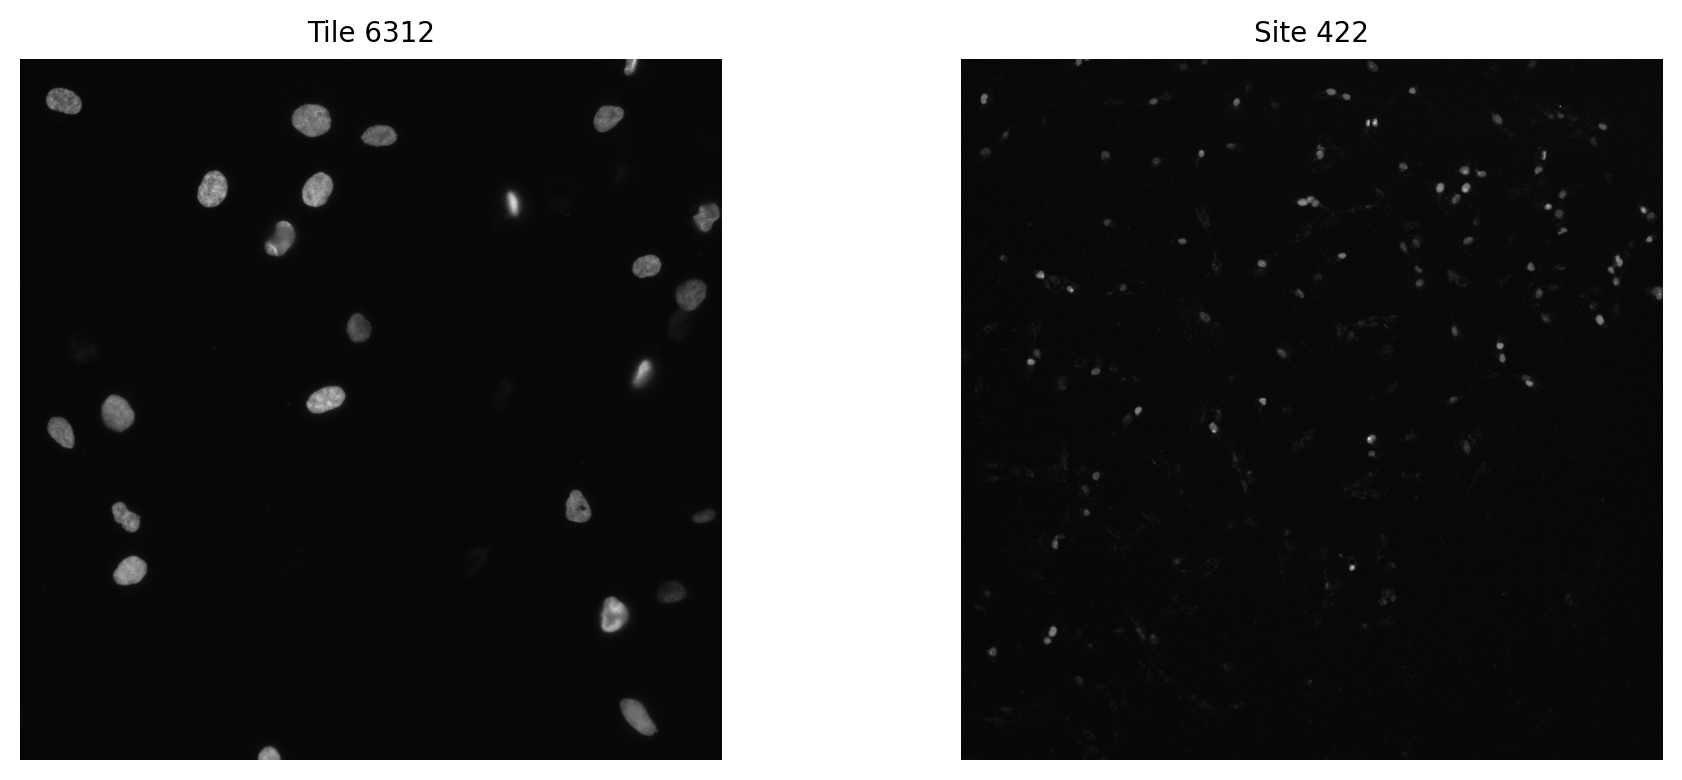

In [68]:
tile_nd2_dir = Path("/lab/ops_data/nebo/plate_1/input_ph/round_1/20250406_101736_609") 
# tile_nd2_dir = Path("/lab/ops_data/nebo/plate_1/input_ph/round_1/20250403_160659_394")
site_nd2_dir = Path("/lab/ops_data/nebo/plate_1/input_sbs/c1/10x")

tile_pattern = re.compile(r"P\d+_Wells-(?P<well>[A-H]\d)_Points-(?P<point>\d+).*\.nd2")
site_pattern = re.compile(r"P\d+_Wells-(?P<well>[A-H]\d)_Points-(?P<point>\d+).*\.nd2")

well="A3"
tile= 6312
site= 422

display_tile_site_pair(well,
                          tile,
                          site,
                          tile_nd2_dir,
                          site_nd2_dir,
                          tile_pattern,
                          site_pattern)
